In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# Physics Problem

## Newton's Law of Cooling:


- dT/dt + k(T - T_room) = 0
- k = 0.1
- T_room = 25
- Initial condition: T(0) = 100

In [3]:
k = 0.1
T_room = 25.0
T_initial = 100.0

# Model

In [5]:
class PINN(nn.Module):

  def __init__(self):
    super().__init__()

    self.network=nn.Sequential(
        nn.Linear(1,32),
        nn.Tanh(),

        nn.Linear(32,32),
        nn.Tanh(),

        nn.Linear(32,32),
        nn.Tanh(),

        nn.Linear(32,1)

    )
  def forward(self,t):

    return self.network(t)

In [6]:
model=PINN().to(device)

In [7]:
model

PINN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Optimizer

In [8]:
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Collition Points

In [17]:
N_collation=1000

t_physics=torch.linspace(
    0,10,N_collation,device=device).reshape(-1,1)
print(t_physics.shape)

torch.Size([1000, 1])


In [21]:
t_physics.requires_grad_(True)
print(t_physics[:10])

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0501],
        [0.0601],
        [0.0701],
        [0.0801],
        [0.0901]], device='cuda:0', grad_fn=<SliceBackward0>)


# Training

In [23]:
epochs=5000

loss_history=[]


for epoch in range(epochs):

  optimizer.zero_grad()

  #forward pass
  T_pred=model(t_physics)

  #calculate derivative
  dT_dt=torch.autograd.grad(
      outputs=T_pred,
      inputs=t_physics,
      grad_outputs=torch.ones_like(T_pred),
      create_graph=True
  )[0]

  #physics loss/residual

  residual=(
      dT_dt+k*(T_pred-T_room)
  )

  physics_loss=torch.mean(residual**2)

  # Initial Condition
  t0=torch.zeros(
      (1,1),device=device,
      requires_grad=True
  )

  T0_pred=model(t0)

  #initial condition loss
  ic_loss=torch.mean(
      (T0_pred-T_initial)**2
  )

  #totalloss
  total_loss=physics_loss+ic_loss

  #Backpropagation
  total_loss.backward()

  #weight_update
  optimizer.step()


  loss_history.append(total_loss.item())

  if epoch%500==0:
    print(f"Epoch:{epoch:5d} | phy_loss:{physics_loss.item():4f} | ic_loss:{ic_loss.item():4f} | total_loss:{total_loss.item():4f}")

print('Training Done')

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch:    0 | phy_loss:6.080019 | ic_loss:9995.159180 | total_loss:10001.239258
Epoch:  500 | phy_loss:0.224833 | ic_loss:6356.760254 | total_loss:6356.984863
Epoch: 1000 | phy_loss:1.021918 | ic_loss:4209.601074 | total_loss:4210.623047
Epoch: 1500 | phy_loss:0.525926 | ic_loss:2657.577148 | total_loss:2658.103027
Epoch: 2000 | phy_loss:0.387432 | ic_loss:1568.739380 | total_loss:1569.126831
Epoch: 2500 | phy_loss:0.238377 | ic_loss:846.312683 | total_loss:846.551086
Epoch: 3000 | phy_loss:0.181969 | ic_loss:404.357819 | total_loss:404.539795
Epoch: 3500 | phy_loss:0.147469 | ic_loss:163.844772 | total_loss:163.992249
Epoch: 4000 | phy_loss:0.116487 | ic_loss:53.066166 | total_loss:53.182652
Epoch: 4500 | phy_loss:0.082952 | ic_loss:12.703857 | total_loss:12.786810
Training Done


# prediction

In [24]:
t_test=torch.linspace(
    0,10,200,device=device
).reshape(-1,1)

with torch.no_grad():
  T_pred_test=model(t_test)


t_test_cpu=t_test.cpu()

T_pred_cpu=T_pred_test.cpu()

#Exact Analytical Solution

In [26]:
T_exac=T_room+(T_initial-T_room)*torch.exp(-k*t_test_cpu)


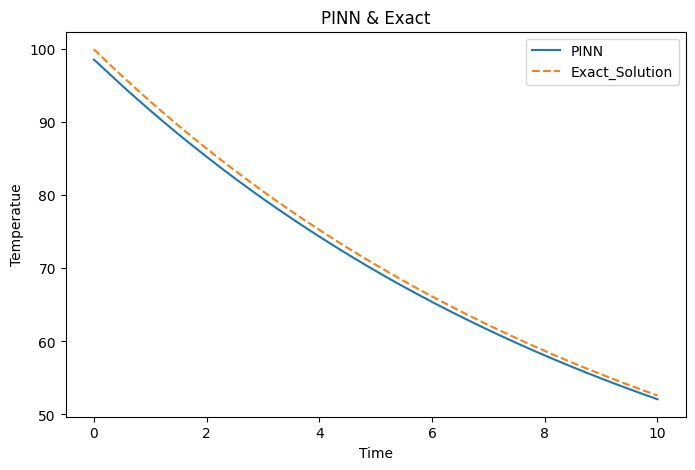

In [29]:
plt.figure(figsize=(8,5))

plt.plot(t_test_cpu.numpy(),T_pred_cpu.numpy(),label="PINN")

plt.plot(t_test_cpu.numpy(),T_exac.numpy(),"--",label="Exact_Solution")

plt.xlabel("Time")
plt.ylabel("Temperatue")

plt.legend()
plt.title("PINN & Exact")

plt.show()